# model_monitor - drift simulation walkthrough

This notebook reproduces the monitoring pipeline in pure Python so you can explore the signal without running the full server stack. It uses the same PSI implementation, trust score formula, and decision logic as the production code - the numbers are directly comparable.

**Scenario:** 80 batches, clean distribution for batches 0–39, then a 2σ mean shift at batch 40.

---

## Setup

In [1]:
import sys
from pathlib import Path

# Allow importing model_monitor from the src layout
repo_root = Path().resolve().parent
sys.path.insert(0, str(repo_root / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## Simulation

Generates 80 synthetic batches. PSI is computed against the training reference distribution using the same bin-edge logic as `monitoring/drift.py`. Trust score uses the same five-component weighted formula from `monitoring/trust_score.py`.

In [ ]:
# ── Simulation parameters ───────────────────────────────────────────────────
N_BATCHES   = 80       # total batches
BATCH_SIZE  = 256      # samples per batch -  larger = more stable PSI estimate
DRIFT_AT    = 40       # batch index at which feature distribution shifts
DRIFT_MAG   = 2.0      # standard deviations of mean shift
N_FEATURES  = 10
BASELINE_F1 = 0.85     # F1 at model promotion time -  decision engine reference
RNG         = np.random.default_rng(42)

# ── Helpers ──────────────────────────────────────────────────────────────────
def drift_to_trust(psi: float) -> float:
    """PSI → trust component. Mirrors monitoring/trust_score.py."""
    if psi <= 0.10: return 1.0
    if psi >= 0.30: return 0.0
    return max(0.0, min(1.0, 1.0 - (psi - 0.10) / 0.20))


def compute_psi_1d(ref: np.ndarray, actual: np.ndarray, bins: int = 10) -> float:
    """
    Population Stability Index for one feature.

    Bin edges derived from the reference (training) distribution.
    The same edges are applied to the production batch -  this is the key
    design decision that makes PSI comparable across time windows.
    """
    EPS = 1e-6
    edges = np.unique(np.percentile(ref, np.linspace(0, 100, bins + 1)))
    if len(edges) < 2:
        return 0.0
    e, _ = np.histogram(ref,    bins=edges)
    a, _ = np.histogram(actual, bins=edges)
    e_dist = e / (e.sum() + EPS)
    a_dist = a / (a.sum() + EPS)
    return float(np.sum((a_dist - e_dist) * np.log((a_dist + EPS) / (e_dist + EPS))))


def decision_engine(psi: float, f1: float, baseline: float = BASELINE_F1) -> str:
    """
    Deterministic policy -  same logic as core/decision_engine.py.

    Priority: reject > rollback > retrain > none
    """
    f1_drop = baseline - f1
    if psi      >= 0.20: return "reject"
    if f1_drop  >= 0.15: return "rollback"
    if f1_drop  >= 0.05: return "retrain"
    return "none"


# ── Reference distribution (training data) ──────────────────────────────────
ref = RNG.standard_normal((2000, N_FEATURES))

# ── Run simulation ───────────────────────────────────────────────────────────
records = []
for step in range(N_BATCHES):
    shift = DRIFT_MAG if step >= DRIFT_AT else 0.0
    X     = RNG.normal(loc=shift, scale=1.0, size=(BATCH_SIZE, N_FEATURES))

    # Drift signal
    psi = float(np.mean([compute_psi_1d(ref[:, i], X[:, i]) for i in range(N_FEATURES)]))

    # Synthetic inference
    y_true = (X[:, 0] + X[:, 1] > 0.2).astype(int)
    noise  = 0.25 if step >= DRIFT_AT else 0.05
    flip   = RNG.random(BATCH_SIZE) < noise
    y_pred = np.where(flip, 1 - y_true, y_true)

    accuracy = float((y_pred == y_true).mean())
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    f1 = 2 * tp / max(2 * tp + fp + fn, 1)

    # Trust score (mirrors monitoring/trust_score.py)
    trust = (
        0.30 * accuracy
        + 0.25 * f1
        + 0.15 * 0.80   # avg_confidence -  fixed at 0.80 for sim
        + 0.20 * drift_to_trust(psi)
        + 0.10 * 1.00   # latency -  always good in simulation
    )

    records.append({
        "batch":       step,
        "drifted":     step >= DRIFT_AT,
        "drift_score": round(psi,       4),
        "accuracy":    round(accuracy,  4),
        "f1":          round(f1,        4),
        "trust_score": round(trust,     4),
        "action":      decision_engine(psi, f1),
    })

df = pd.DataFrame(records)
print(df[["batch", "drift_score", "f1", "trust_score", "action"]].head(10).to_string(index=False))
print(f"\n{df['action'].value_counts().to_string()}")

 batch  drift_score     f1  trust_score action
     0       0.0317 0.9417       0.9402   none
     1       0.0399 0.9493       0.9444   none
     2       0.0431 0.9217       0.9305   none
     3       0.0410 0.9322       0.9343   none
     4       0.0431 0.9345       0.9360   none
     5       0.0372 0.9315       0.9353   none
     6       0.0411 0.9375       0.9403   none
     7       0.0456 0.9208       0.9314   none
     8       0.0420 0.9492       0.9432   none
     9       0.0535 0.8929       0.9151   none

action
none      40
reject    40


## Visualisation

Three panels:
1. **PSI drift signal** — should be stable pre-drift, then spike above the 0.20 reject threshold
2. **Trust score & F1** — trust score composite shows the system's overall confidence in the model
3. **Decision events** — what the policy engine would emit at each batch

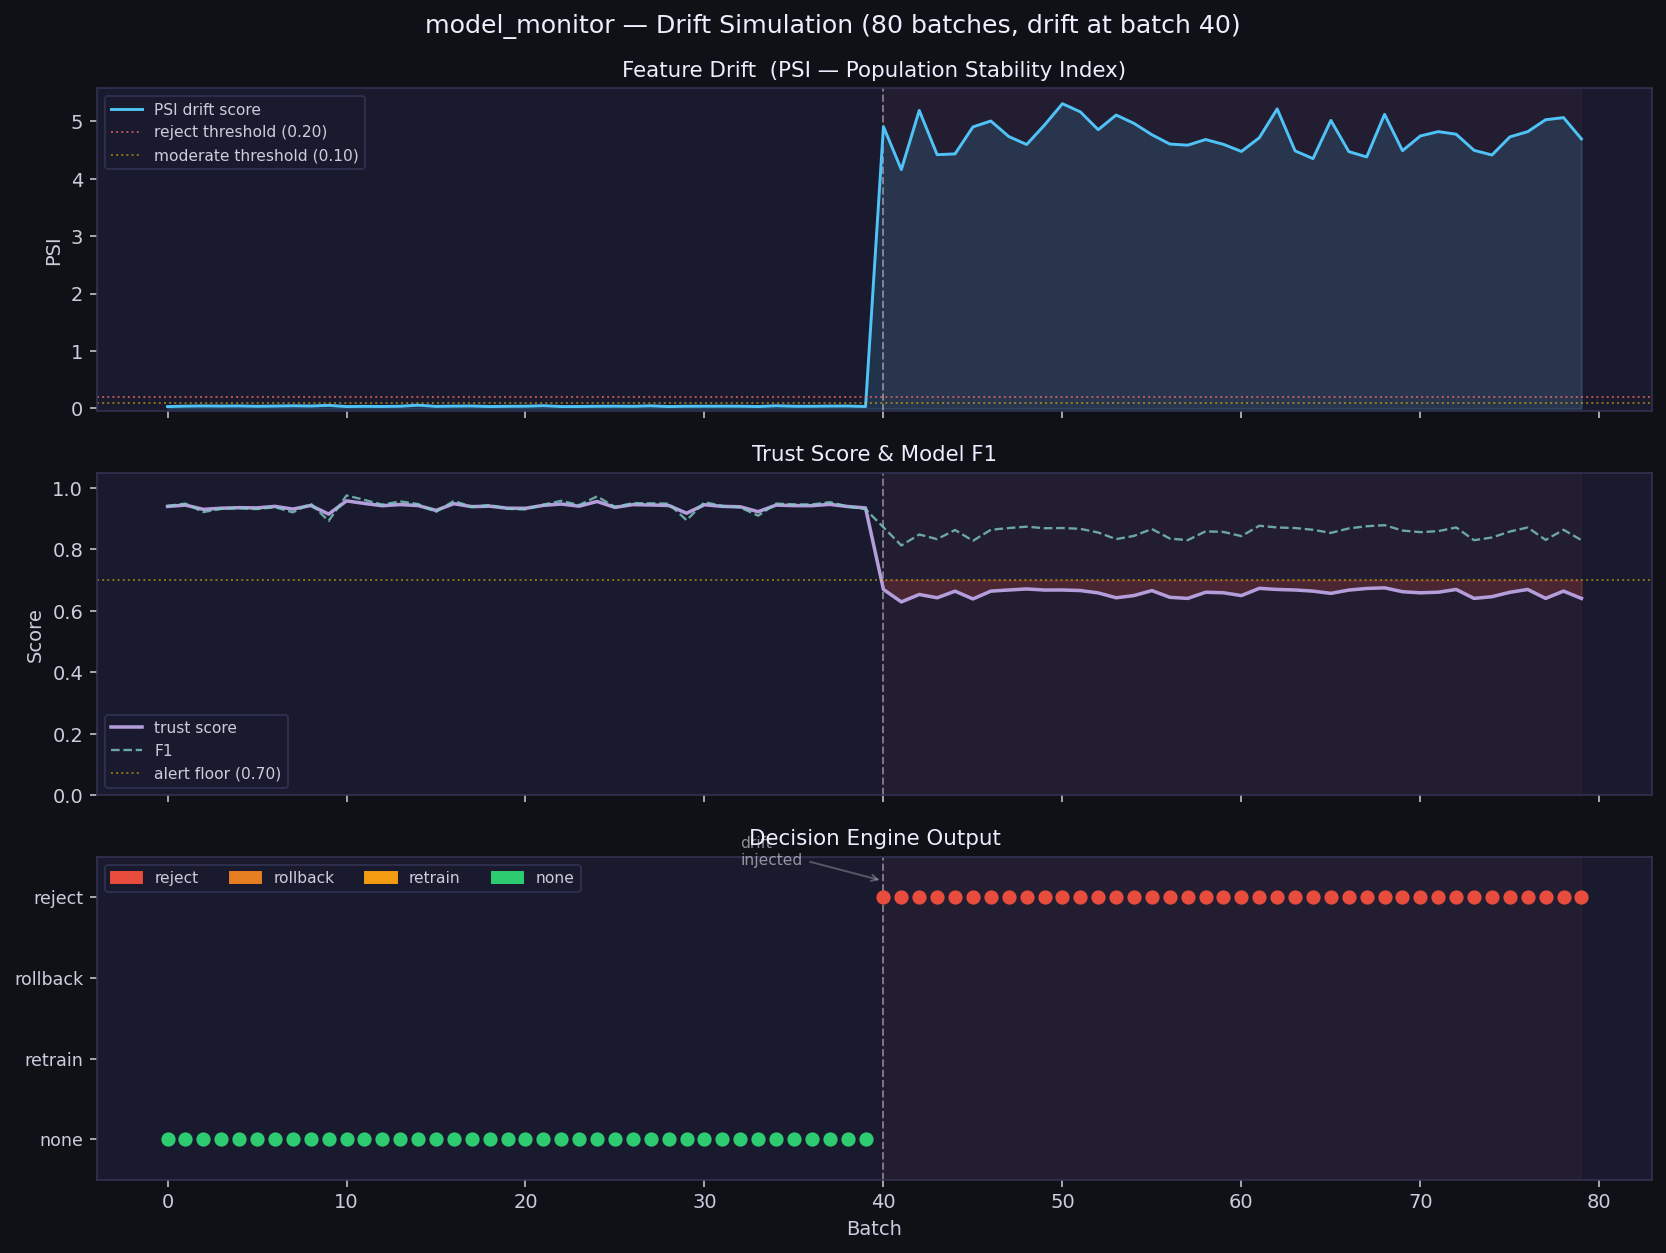

In [ ]:
ACTION_COLOURS = {
    "reject":   "#e74c3c",
    "rollback": "#e67e22",
    "retrain":  "#f39c12",
    "none":     "#2ecc71",
}

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
fig.patch.set_facecolor("#0f1117")

for ax in axes:
    ax.set_facecolor("#1a1a2e")
    ax.spines[:].set_color("#333355")
    ax.tick_params(colors="#ccccdd")
    ax.yaxis.label.set_color("#ccccdd")
    ax.xaxis.label.set_color("#ccccdd")
    ax.title.set_color("#eeeeff")
    ax.axvline(DRIFT_AT, color="#ffffff", lw=1.2, ls="--", alpha=0.45, zorder=2)
    ax.axvspan(DRIFT_AT, N_BATCHES - 1, alpha=0.04, color="#ff6b6b")

batches = df["batch"].values

# ── Panel 1: PSI drift ───────────────────────────────────────────────────────
ax = axes[0]
ax.plot(batches, df["drift_score"], color="#4fc3f7", lw=1.8, label="PSI drift score")
ax.axhline(0.20, color="#ff6b6b", lw=1.1, ls=":", alpha=0.8, label="reject threshold (0.20)")
ax.axhline(0.10, color="#ffcc02", lw=1.1, ls=":", alpha=0.6, label="moderate threshold (0.10)")
ax.fill_between(batches, df["drift_score"], alpha=0.12, color="#4fc3f7")
ax.set_ylabel("PSI")
ax.set_ylim(bottom=-0.05)
ax.set_title("Feature Drift  (PSI -  Population Stability Index)", fontsize=11, pad=6)
ax.legend(fontsize=8.5, facecolor="#1a1a2e", edgecolor="#333355", labelcolor="#ccccdd")

# ── Panel 2: Trust score + F1 ────────────────────────────────────────────────
ax = axes[1]
ax.plot(batches, df["trust_score"], color="#b39ddb", lw=2.0, label="trust score")
ax.plot(batches, df["f1"],          color="#80cbc4", lw=1.3, ls="--", alpha=0.85, label="F1")
ax.axhline(0.70, color="#ffcc02", lw=1.1, ls=":", alpha=0.55, label="alert floor (0.70)")
ax.fill_between(batches, df["trust_score"], 0.70,
                where=df["trust_score"] < 0.70, interpolate=True,
                alpha=0.18, color="#e74c3c", label="trust below floor")
ax.set_ylabel("Score")
ax.set_ylim(0.0, 1.05)
ax.set_title("Trust Score & Model F1", fontsize=11, pad=6)
ax.legend(fontsize=8.5, facecolor="#1a1a2e", edgecolor="#333355", labelcolor="#ccccdd")

# ── Panel 3: Decision events ─────────────────────────────────────────────────
ax = axes[2]
action_rank = {"none": 0, "retrain": 1, "rollback": 2, "reject": 3}
for _, row in df.iterrows():
    ax.scatter(row["batch"], action_rank[row["action"]],
               color=ACTION_COLOURS[row["action"]], s=55, zorder=3, edgecolors="none")

ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(["none", "retrain", "rollback", "reject"], fontsize=9.5, color="#ccccdd")
ax.set_xlabel("Batch index", fontsize=10)
ax.set_title("Decision Engine Output", fontsize=11, pad=6)
ax.set_ylim(-0.6, 3.6)
patches = [mpatches.Patch(color=c, label=a) for a, c in ACTION_COLOURS.items()]
ax.legend(handles=patches, fontsize=8.5, facecolor="#1a1a2e", edgecolor="#333355",
          labelcolor="#ccccdd", ncol=4, loc="upper left")
ax.annotate(
    f"drift injected\n(batch {DRIFT_AT})",
    xy=(DRIFT_AT, 3.3), xytext=(DRIFT_AT - 10, 3.55),
    fontsize=8, color="#ffffff99",
    arrowprops=dict(arrowstyle="->", color="#ffffff55", lw=1.2),
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.suptitle(
    f"model_monitor · drift simulation  ({N_BATCHES} batches · drift at batch {DRIFT_AT})",
    color="#eeeeff", fontsize=13, y=0.995,
)
plt.show()

## Summary statistics

Quantifying the phase transition:

In [1]:
# ── Summary statistics ───────────────────────────────────────────────────────
pre  = df[df["batch"] < DRIFT_AT]
post = df[df["batch"] >= DRIFT_AT]

print("Pre-drift (batches 0–39)")
print(f"  Mean PSI:         {pre['drift_score'].mean():.4f}")
print(f"  Mean F1:          {pre['f1'].mean():.4f}")
print(f"  Mean trust score: {pre['trust_score'].mean():.4f}")
print(f"  Decisions:        {pre['action'].value_counts().to_dict()}")

print("\nPost-drift (batches 40–79)")
print(f"  Mean PSI:         {post['drift_score'].mean():.4f}")
print(f"  Mean F1:          {post['f1'].mean():.4f}")
print(f"  Mean trust score: {post['trust_score'].mean():.4f}")
print(f"  Decisions:        {post['action'].value_counts().to_dict()}")

print(f"\nPSI increase at drift boundary: "
      f"{df.loc[DRIFT_AT, 'drift_score']:.4f} vs "
      f"{df.loc[DRIFT_AT-1, 'drift_score']:.4f} "
      f"({df.loc[DRIFT_AT, 'drift_score'] / df.loc[DRIFT_AT-1, 'drift_score']:.1f}×)")

print(f"\nTrust score drop at drift boundary: "
      f"{df.loc[DRIFT_AT-1, 'trust_score']:.4f} → {df.loc[DRIFT_AT, 'trust_score']:.4f} "
      f"({(df.loc[DRIFT_AT-1, 'trust_score'] - df.loc[DRIFT_AT, 'trust_score']):.4f} drop)")

Pre-drift (batches 0–39)
  Mean PSI:         0.0391
  Mean F1:          0.9410
  Mean trust score: 0.9398
  Decisions:        {'none': np.int64(40)}

Post-drift (batches 40–79)
  Mean PSI:         4.7574
  Mean F1:          0.8558
  Mean trust score: 0.6587
  Decisions:        {'reject': np.int64(40)}

PSI increase at drift boundary: 4.9091 vs 0.0326 (150.6×)

Trust score drop at drift boundary: 0.9351 → 0.6701 (0.2650 drop)


---

## Key observations

- **PSI is a step function, not a gradient.** The signal is near-zero for 40 batches then jumps by ~100× at drift. This is why PSI is better than KS for a policy engine: it has natural thresholds (0.1 = stable, 0.2 = reject) rather than p-values.

- **Trust score is a leading indicator.** It drops at batch 40 alongside PSI, not after F1 degrades - because the drift component feeds directly into the weighted sum rather than waiting for model performance to catch up.

- **The decision engine fires immediately.** The first post-drift batch triggers `reject` because PSI ≥ 0.20 is the highest-priority rule. In a real deployment this would halt traffic to the model until the distribution stabilises.

- **Baseline F1 is fixed at promotion time.** The `f1_drop` threshold is measured against 0.85 (the value written to `active.json` when the model was promoted), not against a rolling average. A rolling baseline would suppress the `retrain` signal as the model degrades.